# How do commit habits vary between AI agents?
#### Do some agents have more additions, deletions, or changes per commit than others?
#### Do some agents commit more per pull request than others?

In [26]:
#### Author: Jamie Breault (26478172)

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request

# Importing data [ChatGPT helped with pr_commit_details since I had trouble with the recommended method]

url = "https://huggingface.co/datasets/hao-li/AIDev/resolve/main/pr_commit_details.parquet"
local_file = "pr_commit_details.parquet"
urllib.request.urlretrieve(url, local_file)

cds = pd.read_parquet(local_file)
prs = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")

In [28]:
prs.head()

,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url
0,3264933329,2911,Fix: Wait for all partitions in load_collectio...,## Summary\n\nFixes an issue where `load_colle...,Claude_Code,108661493,weiliu1031,closed,2025-07-26T02:59:01Z,2025-07-29T07:01:20Z,None,191751505,https://api.github.com/repos/milvus-io/pymilvus,https://github.com/milvus-io/pymilvus/pull/2911
1,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,Claude_Code,61827001,cm-kojimat,closed,2025-07-26T04:56:55Z,2025-07-26T22:12:24Z,2025-07-26T22:12:24Z,1025472321,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2
2,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26T13:31:19Z,2025-07-26T13:37:22Z,2025-07-26T13:37:22Z,988488798,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30
3,3265709660,205,feat: add comprehensive README screenshots wit...,## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...,Claude_Code,80381,sugyan,closed,2025-07-26T14:07:22Z,2025-07-26T14:45:30Z,2025-07-26T14:45:30Z,999285986,https://api.github.com/repos/sugyan/claude-cod...,https://github.com/sugyan/claude-code-webui/pu...
4,3265782173,17625,chore: remove HashedPostStateProvider trait,## Summary\r\n\r\n#17545 \r\n\r\nRemove the un...,Claude_Code,47593288,adust09,open,2025-07-26T15:02:48Z,None,None,537233603,https://api.github.com/repos/paradigmxyz/reth,https://github.com/paradigmxyz/reth/pull/17625


In [29]:
# Filtering out columns that won't be used

cds = cds[["sha", "pr_id", "additions", "deletions", "changes"]]
prs = prs[["id", "agent", "merged_at"]]

# Merging the tables

mergedCols = ["id", "agent", "sha", "merged_at", "additions", "deletions", "changes"]
merged = prs.merge(cds, left_on="id", right_on="pr_id", how="left")[mergedCols]

# Checking for null values

merged.isnull().sum()

id                0
agent             0
sha              16
merged_at    271644
additions      5148
deletions      5148
changes        5148
dtype: int64

In [30]:
# Interpolating null additions, changes, and deletions [ChatGPT helped]

interpolationCols = ["additions", "changes", "deletions"]
merged[interpolationCols] = merged[interpolationCols].interpolate(method="linear")

# Filtering out null sha

merged = merged.dropna(subset=["sha"])

# New dataframe for pull requests that have been merged

mergedIn = merged.dropna(subset=["merged_at"])

# Checking for null values again

merged.isnull().sum(), mergedIn.isnull().sum()

(id                0
 agent             0
 sha               0
 merged_at    271628
 additions         0
 deletions         0
 changes           0
 dtype: int64,
 id           0
 agent        0
 sha          0
 merged_at    0
 additions    0
 deletions    0
 changes      0
 dtype: int64)

In [31]:
# Averaging additions, deletions, and changes per commit by agent

avgs_per_agent = (
    merged.groupby(["agent"])
          .agg({
              "additions": "mean",
              "deletions": "mean",
              "changes": "mean"
          })
          .reset_index()
)

# Sorting by the sum of additions, deletions, and changes [ChatGPT helped]

avgs_per_agent["total"] = avgs_per_agent[["additions", "deletions", "changes"]].sum(axis=1)
avgs_per_agent = avgs_per_agent.sort_values("total", ascending=False)

# Counting commits per pull request 

commits_per_pr = (
    merged.groupby(["id", "agent"])
          .sha
          .count()
          .reset_index()
)

# Averaging commits_per_pr by agent

avg_commits_per_pr = (
    commits_per_pr.groupby("agent")
        .sha
        .mean()
        .reset_index()
        .sort_values("sha", ascending=False)
)

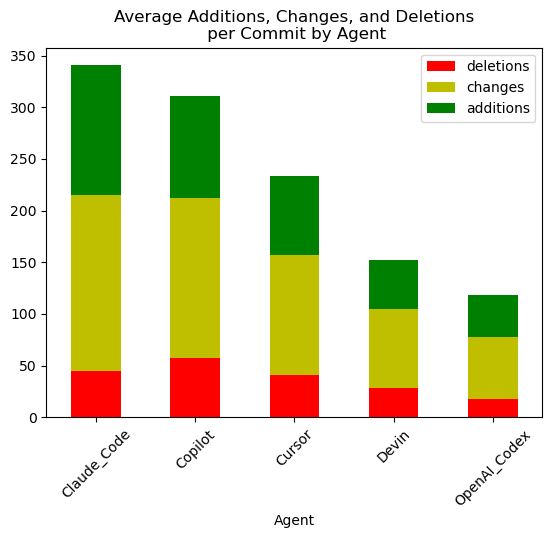

In [32]:
# Plotting Average Commit Additions, Changes, and Deletions per Commit by Agent

avgs_per_agent.plot(kind = "bar", 
                   x = "agent", 
                   y = ["deletions", "changes", "additions"], 
                   stacked = True, 
                   legend = True, 
                   color = ["r", "y", "g"])

plt.title("Average Additions, Changes, and Deletions\n per Commit by Agent")
plt.xlabel("Agent")

plt.xticks(rotation=45)
plt.show()

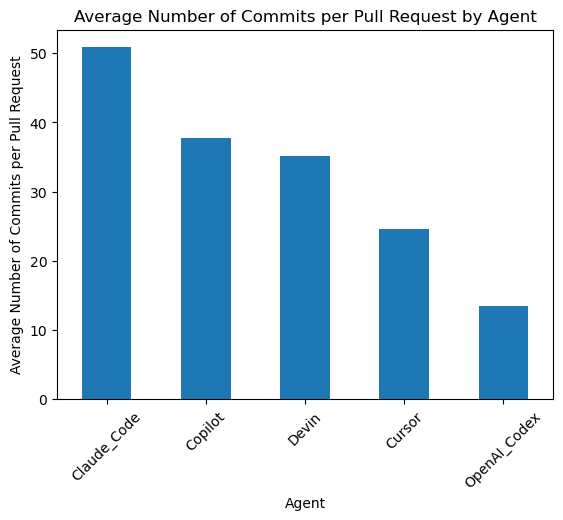

In [33]:
# Plotting Average Number of Commits per Pull Request by Agent

avg_commits_per_pr.plot(kind = "bar", 
                        x = "agent", 
                        y = "sha", 
                        legend = False)

plt.title("Average Number of Commits per Pull Request by Agent")
plt.xlabel("Agent")
plt.ylabel("Average Number of Commits per Pull Request")

plt.xticks(rotation=45)
plt.show()

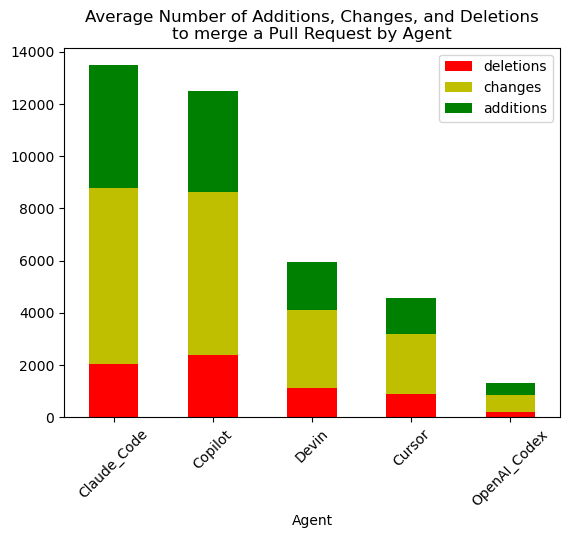

In [38]:
# Plotting Average Additions, Changes, and Deletions per Pull Request by Agent

avgs_per_agent_total = (
    mergedIn.groupby(["id", "agent"])
            .agg({
                "additions": "sum",
                "deletions": "sum",
                "changes": "sum"
            })
            .reset_index()
            .groupby("agent")
            .agg({
                "additions": "mean",
                "deletions": "mean",
                "changes": "mean"
            })
            .reset_index()
)

# Sorting by the sum of additions, deletions, and changes

avgs_per_agent_total["total"] = avgs_per_agent_total[["additions", "deletions", "changes"]].sum(axis=1)
avgs_per_agent_total = avgs_per_agent_total.sort_values("total", ascending=False)


avgs_per_agent_total.plot(kind = "bar", 
                          x = "agent", 
                          y = ["deletions", "changes", "additions"], 
                          stacked = True, 
                          legend = True, 
                          color = ["r", "y", "g"])

plt.title("Average Number of Additions, Changes, and Deletions\nto merge a Pull Request by Agent")
plt.xlabel("Agent")

plt.xticks(rotation=45)
plt.show()